<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/LAB%20MANUAL%20QUESTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1)Lab 1: FIND-S Algorithm,

In [ ]:
import csv

# 1. Create sample 'enjoysport.csv' directly in Google Colab environment
sample_data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

with open('enjoysport.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(sample_data)

# 2. FIND-S Algorithm Implementation
def find_s(filename):
    with open(filename) as f:
        data = list(csv.reader(f))

        # Initialize hypothesis with the most specific hypothesis '0'
        hypothesis = ['0'] * (len(data[0]) - 1)

        for row in data:
            # Process only positive examples ('Yes')
            if row[-1].strip().lower() == 'yes':
                for i in range(len(hypothesis)):
                    if hypothesis[i] == '0':
                        hypothesis[i] = row[i]
                    elif hypothesis[i] != row[i]:
                        hypothesis[i] = '?'

    return hypothesis

# 3. Execute and display result
result_hypothesis = find_s('enjoysport.csv')
print("Most specific hypothesis:", result_hypothesis)

Most specific hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']


Lab 2: Candidate-Elimination Algorithm.

In [ ]:
import numpy as np
import pandas as pd

# 1. Create sample 'enjoysport.csv' directly in Google Colab environment
sample_data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

pd.DataFrame(sample_data).to_csv('enjoysport.csv', index=False)

# 2. Candidate-Elimination Implementation
def candidate_elimination(filename):
    data = pd.read_csv(filename)
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

    num_attributes = X.shape[1]

    # Initialize Specific (S) and General (G) boundaries
    S = ['0'] * num_attributes
    G = [['?'] * num_attributes]

    # Find the first positive example to initialize S properly
    for i, target in enumerate(y):
        if target.strip().lower() == 'yes':
            S = list(X[i])
            break

    for i in range(len(X)):
        if y[i].strip().lower() == 'yes':
            # For Positive Example: Generalize S
            for j in range(num_attributes):
                if S[j] != X[i][j]:
                    S[j] = '?'

            # Prune G to keep only hypotheses consistent with positive example
            G = [g for g in G if all(g[k] == '?' or g[k] == X[i][k] for k in range(num_attributes))]

        else:
            # For Negative Example: Specialize G
            new_G = []
            for g in G:
                for j in range(num_attributes):
                    if g[j] == '?' and S[j] != '?' and S[j] != X[i][j]:
                        g_special = g.copy()
                        g_special[j] = S[j]
                        if g_special not in new_G:
                            new_G.append(g_special)
            G = new_G if new_G else G

    return S, G

# 3. Execute and display result
S_final, G_final = candidate_elimination('enjoysport.csv')

print("Final S (Specific Boundary):", S_final)
print("Final G (General Boundary):", G_final)

Final S (Specific Boundary): ['Sunny', 'Warm', '?', 'Strong', '?', '?']
Final G (General Boundary): [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?']]


Lab 3: Decision Tree Learning (ID3)

In [ ]:
import pandas as pd
import numpy as np

# 1. Create sample 'playtennis.csv' directly in Google Colab environment
sample_data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

pd.DataFrame(sample_data).to_csv('playtennis.csv', index=False)

# 2. Entropy and Information Gain Functions
def entropy(col):
    vals, counts = np.unique(col, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

def info_gain(data, attr, target):
    total_entropy = entropy(data[target])
    vals, counts = np.unique(data[attr], return_counts=True)
    weighted = sum((counts[i] / counts.sum()) *
                   entropy(data[data[attr] == vals[i]][target]) for i in range(len(vals)))
    return total_entropy - weighted

# 3. ID3 Decision Tree Algorithm
def id3(data, attrs, target):
    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]
    if not attrs:
        return data[target].mode()[0]

    gains = {a: info_gain(data, a, target) for a in attrs}
    best = max(gains, key=gains.get)
    tree = {best: {}}

    for v in np.unique(data[best]):
        subset = data[data[best] == v]
        remaining = [a for a in attrs if a != best]
        tree[best][v] = id3(subset, remaining, target)

    return tree

# 4. Helper Function to Classify a New Sample
def classify(tree, sample):
    if not isinstance(tree, dict):
        return tree
    root = list(tree.keys())[0]
    val = sample.get(root)
    if val in tree[root]:
        return classify(tree[root][val], sample)
    return "Unknown"

# 5. Build and Output Decision Tree
df = pd.read_csv('playtennis.csv')
target_col = df.columns[-1]
attributes = list(df.columns[:-1])

decision_tree = id3(df, attributes, target_col)
print("Decision Tree:")
print(decision_tree)

# 6. Test Classification on a New Sample
new_sample = {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Weak'}
prediction = classify(decision_tree, new_sample)
print("\nNew Sample Prediction:", prediction)

Decision Tree:
{'Outlook': {'Overcast': 'Yes', 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}

New Sample Prediction: No


Lab 4: Decision Tree using scikit-learn with Visualisation.

Accuracy: 0.9555555555555556


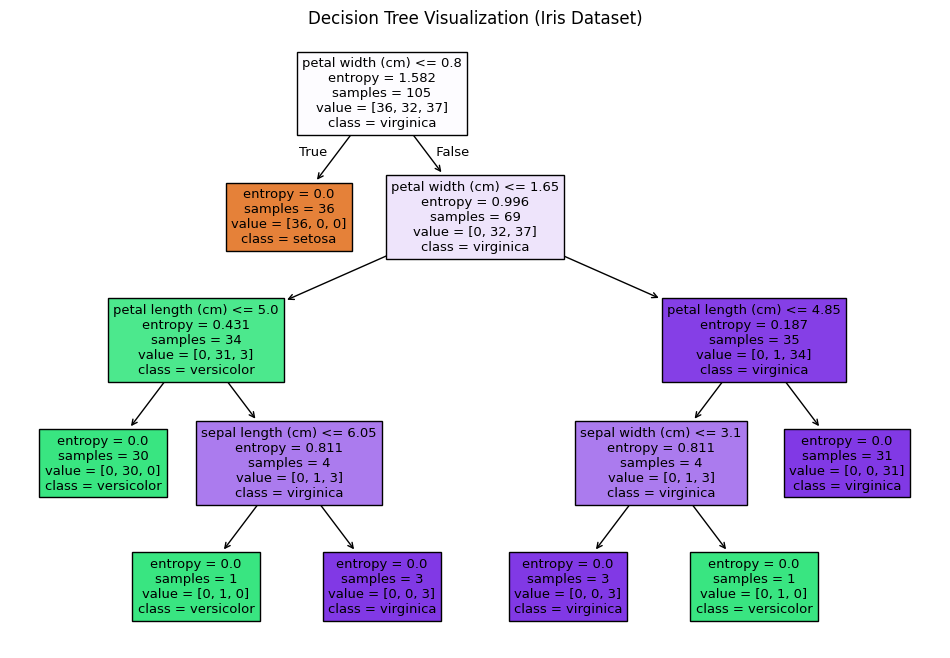

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. Load Iris dataset
iris = load_iris()

# 2. Split dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=1
)

# 3. Initialize and fit the DecisionTreeClassifier using Entropy
clf = DecisionTreeClassifier(criterion='entropy', random_state=1)
clf.fit(X_train, y_train)

# 4. Predict and print accuracy
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 5. Plot and display the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree Visualization (Iris Dataset)")
plt.savefig('iris_tree.png')
plt.show()

Lab 5: Single-Layer Perceptron (AND / OR Gate).

In [ ]:
import numpy as np

# 1. Perceptron Training Function
def perceptron_train(X, y, epochs=20, lr=0.1):
    # Initialize weights (including bias weight at index 0)
    w = np.zeros(X.shape[1] + 1)

    for _ in range(epochs):
        for xi, target in zip(X, y):
            # Insert bias unit (x0 = 1) at position 0
            xi_b = np.insert(xi, 0, 1)

            # Step activation function
            out = 1 if np.dot(w, xi_b) > 0 else 0

            # Perceptron weight update rule: Δw = η * (target - output) * x
            w += lr * (target - out) * xi_b

    return w

# 2. Helper function to test and print gate outputs
def test_gate(gate_name, X, w):
    print(f"\n--- {gate_name} Gate Testing ---")
    print("Learned weights (Bias, W1, W2):", w)
    print("Input -> Predicted Output")
    for xi in X:
        xi_b = np.insert(xi, 0, 1)
        pred = 1 if np.dot(w, xi_b) > 0 else 0
        print(f"{xi} -> {pred}")

# 3. Input Truth Table Inputs
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Target outputs
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])

# Train and Test AND Gate
w_and = perceptron_train(X, y_and)
test_gate("AND", X, w_and)

# Train and Test OR Gate
w_or = perceptron_train(X, y_or)
test_gate("OR", X, w_or)


--- AND Gate Testing ---
Learned weights (Bias, W1, W2): [-0.2  0.2  0.1]
Input -> Predicted Output
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

--- OR Gate Testing ---
Learned weights (Bias, W1, W2): [0.  0.1 0.1]
Input -> Predicted Output
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


Lab 6 — Perceptron using scikit-learn.

Accuracy: 0.8833333333333333


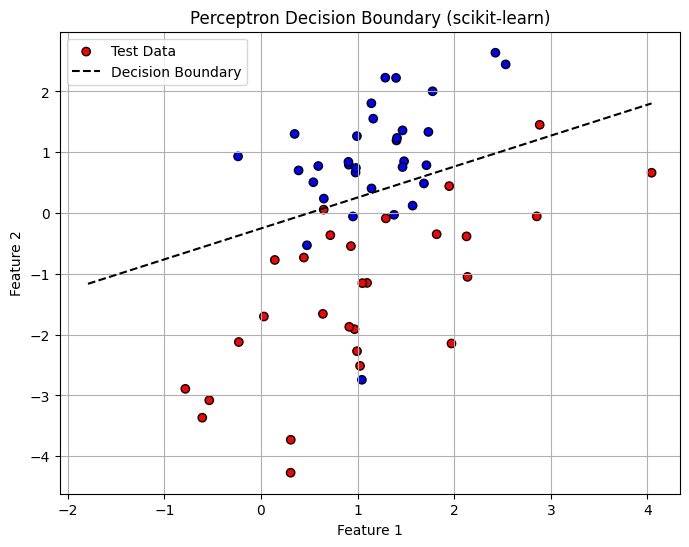

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# 1. Generate linearly separable binary dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=1
)

# 2. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. Initialize and fit the Perceptron model
model = Perceptron(max_iter=1000, eta0=0.1, random_state=1)
model.fit(X_train, y_train)

# 4. Predict and evaluate accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 5. Plot Decision Boundary
plt.figure(figsize=(8, 6))

# Scatter plot of test data
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', edgecolors='k', label='Test Data')

# Calculate decision boundary hyper-plane line
x_vals = np.array([X[:, 0].min(), X[:, 0].max()])
y_vals = -(model.coef_[0][0] * x_vals + model.intercept_[0]) / model.coef_[0][1]

plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')
plt.title("Perceptron Decision Boundary (scikit-learn)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Lab 7 — Multilayer Perceptron with Backpropagation (XOR) .

In [ ]:
import numpy as np

# 1. Activation function and derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

# 2. XOR Input and Output datasets
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Set seed for reproducible weight initialization
np.random.seed(1)

# 3. Initialize weights randomly
# Input to Hidden layer weights (2 inputs -> 4 hidden neurons)
w1 = np.random.uniform(-1, 1, (2, 4))
# Hidden to Output layer weights (4 hidden neurons -> 1 output neuron)
w2 = np.random.uniform(-1, 1, (4, 1))

lr = 0.5 # Learning rate

# 4. Backpropagation Training Loop
for epoch in range(10000):
    # Forward pass
    h = sigmoid(np.dot(X, w1))
    o = sigmoid(np.dot(h, w2))

    # Compute output layer error and gradient
    err_o = (y - o) * sigmoid_deriv(o)

    # Backpropagate error to hidden layer
    err_h = err_o.dot(w2.T) * sigmoid_deriv(h)

    # Update weights
    w2 += h.T.dot(err_o) * lr
    w1 += X.T.dot(err_h) * lr

# 5. Display Results
print("Predicted output after training:")
for i, xi in enumerate(X):
    print(f"Input: {xi} -> Raw Output: {o[i][0]:.4f} -> Rounded: {np.round(o[i][0])}")

Predicted output after training:
Input: [0 0] -> Raw Output: 0.0317 -> Rounded: 0.0
Input: [0 1] -> Raw Output: 0.9747 -> Rounded: 1.0
Input: [1 0] -> Raw Output: 0.9710 -> Rounded: 1.0
Input: [1 1] -> Raw Output: 0.0279 -> Rounded: 0.0


Lab 8 — Backpropagation Neural Network using scikit-learn (MLPClassifier).

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Iris dataset
X, y = load_iris(return_X_y=True)

# 2. Split dataset into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. Scale features using StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# 4. Initialize and fit MLPClassifier (1 hidden layer with 10 neurons)
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=1)
mlp.fit(X_train, y_train)

# 5. Make predictions and evaluate performance
y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9555555555555556

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



Lab 9 — Introduction to Deep Neural Networks using Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize pixel values between 0.0 and 1.0
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Build Sequential Deep Neural Network Model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 images to 784 1D array
    layers.Dense(128, activation='relu'),   # First hidden layer
    layers.Dense(64, activation='relu'),    # Second hidden layer
    layers.Dense(10, activation='softmax')  # Output layer for 10 digit classes
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
print("Training the Deep Neural Network...")
model.fit(X_train, y_train, epochs=5, validation_split=0.1)

# 6. Evaluate accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the Deep Neural Network...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9234 - loss: 0.2612 - val_accuracy: 0.9690 - val_loss: 0.1096
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9677 - loss: 0.1062 - val_accuracy: 0.9728 - val_loss: 0.0975
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9770 - loss: 0.0735 - val_accuracy: 0.9762 - val_loss: 0.0762
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0558 - val_accuracy: 0.9773 - val_loss: 0.0843
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9857 - loss: 0.0459 - val_accuracy: 0.9755 - val_loss: 0.0835

Test Accuracy: 0.9741


lab 10 — Genetic Algorithm to Maximise a Function

In [ ]:
import random

# 1. Decode binary bit-string chromosome to integer x
def decode(chrom):
    return int(chrom, 2)

# 2. Fitness function f(x) = x^2
def fitness(chrom):
    return decode(chrom) ** 2

# 3. Genetic Algorithm Implementation
def ga(pop_size=6, generations=20, mut_rate=0.05):
    # Initialize random population of 5-bit chromosomes
    population = [''.join(random.choice('01') for _ in range(5)) for _ in range(pop_size)]

    for gen in range(generations):
        fitnesses = [fitness(c) for c in population]
        total = sum(fitnesses)

        # Handle case where all fitnesses might be zero
        if total == 0:
            probs = [1.0 / pop_size] * pop_size
        else:
            probs = [f / total for f in fitnesses]

        # Roulette wheel selection and Crossover
        new_pop = []
        for _ in range(pop_size // 2):
            # Select 2 parents based on fitness weights
            p1, p2 = random.choices(population, weights=probs, k=2)

            # Single-point crossover
            point = random.randint(1, 4)
            c1 = p1[:point] + p2[point:]
            c2 = p2[:point] + p1[point:]
            new_pop.extend([c1, c2])

        # Bit-flip Mutation
        population = []
        for chrom in new_pop:
            mutated_chrom = ''.join(
                b if random.random() > mut_rate else str(1 - int(b))
                for b in chrom
            )
            population.append(mutated_chrom)

    # Find and return best solution in final population
    best = max(population, key=fitness)
    return decode(best), fitness(best)

# 4. Run Genetic Algorithm
best_x, max_fx = ga()
print(f"Best x = {best_x}, f(x) = {max_fx}")

Best x = 27, f(x) = 729


Lab 11 — Genetic Algorithm for the 0/1 Knapsack Problem.

In [ ]:
import random

# Problem Parameters: Item weights, values, and maximum capacity limit
weights = [2, 3, 4, 5]
values = [3, 4, 5, 6]
capacity = 8

# 1. Fitness function: total value if total weight <= capacity, else 0
def fitness(chrom):
    w = sum(weights[i] for i in range(len(chrom)) if chrom[i] == '1')
    v = sum(values[i] for i in range(len(chrom)) if chrom[i] == '1')
    return v if w <= capacity else 0

# 2. Genetic Algorithm for 0/1 Knapsack
def ga_knapsack(pop_size=8, generations=30):
    # Initial random binary population of chromosome length = len(weights)
    pop = [''.join(random.choice('01') for _ in range(4)) for _ in range(pop_size)]

    for _ in range(generations):
        # Keep top population based on fitness
        pop = sorted(pop, key=fitness, reverse=True)[:pop_size]
        children = []

        # Selection, Crossover, and Mutation
        for _ in range(pop_size):
            p1, p2 = random.sample(pop[:4], 2)
            point = random.randint(1, 3)

            # Single-point Crossover
            child = p1[:point] + p2[point:]

            # Bit-flip Mutation (10% mutation rate)
            child = ''.join(b if random.random() > 0.1 else str(1 - int(b)) for b in child)
            children.append(child)

        pop += children

    # Return best chromosome solution and its corresponding value
    best = max(pop, key=fitness)
    return best, fitness(best)

# 3. Execute and display result
sol, val = ga_knapsack()

print("Best solution (Binary Chromosome):", sol)
print("Total Selected Value:", val)
print("Total Selected Weight:", sum(weights[i] for i in range(len(sol)) if sol[i] == '1'))

Best solution (Binary Chromosome): 0101
Total Selected Value: 10
Total Selected Weight: 8


Lab 12 — Genetic Programming for Symbolic Regression (using gplearn).

In [ ]:
# 1. Install gplearn directly in Colab
!pip install gplearn --quiet

import numpy as np
from gplearn.genetic import SymbolicRegressor

# 2. Generate synthetic dataset: y = x^2 + 3x + 2
X = np.linspace(-5, 5, 50).reshape(-1, 1)
y = (X**2 + 3*X + 2).ravel()

# 3. Initialize and fit SymbolicRegressor
est = SymbolicRegressor(
    population_size=500,
    generations=20,
    function_set=('add', 'sub', 'mul'),
    random_state=1,
    verbose=0
)

est.fit(X, y)

# 4. Display the evolved mathematical expression and R^2 fitness score
print("Evolved program:", est._program)
print("R^2 score:", est.score(X, y))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.1 MB/s eta 0:00:00
Evolved program: add(sub(0.941, -0.952), sub(add(add(mul(-0.003, -0.729), sub(add(X0, 0.357), mul(0.358, 0.500))), sub(add(X0, -0.301), sub(-0.509, X0))), sub(mul(sub(0.380, -0.729), add(-0.726, 0.791)), add(mul(X0, X0), mul(0.373, -0.558)))))
R^2 score: 0.9999999994162309


Lab 13 — Bayes Theorem — Posterior Probability Calculator.

In [ ]:
# 1. Bayes Theorem Calculation Function
def bayes(prior, likelihood, evidence):
    """
    Calculates Posterior Probability P(h|D) using Bayes' Theorem:
    P(h|D) = (P(D|h) * P(h)) / P(D)
    """
    return (likelihood * prior) / evidence

# 2. Example Problem Setup: Disease Testing
# Prior probability of having the disease P(Disease)
p_disease = 0.01

# Likelihood: Probability of testing positive given disease P(Pos | Disease)
p_pos_given_disease = 0.99

# False Positive Rate: Probability of testing positive given NO disease P(Pos | No Disease)
p_false_positive = 0.05

# Total Evidence: Total probability of testing positive P(Pos)
# P(Pos) = P(Pos|Disease)*P(Disease) + P(Pos|No Disease)*P(No Disease)
p_pos = (p_pos_given_disease * p_disease) + (p_false_positive * (1 - p_disease))

# 3. Calculate Posterior Probability P(Disease | Positive Test)
posterior = bayes(p_disease, p_pos_given_disease, p_pos)

# 4. Display Results
print(f"Prior Probability P(Disease): {p_disease}")
print(f"Likelihood P(Pos | Disease): {p_pos_given_disease}")
print(f"Total Evidence P(Pos): {p_pos:.4f}")
print(f"Posterior Probability P(Disease | Positive Test) = {posterior:.4f}")

Prior Probability P(Disease): 0.01
Likelihood P(Pos | Disease): 0.99
Total Evidence P(Pos): 0.0594
Posterior Probability P(Disease | Positive Test) = 0.1667


Lab 14 — Naïve Bayes Classifier (Iris Dataset)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 43.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Accuracy: 1.0
Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]


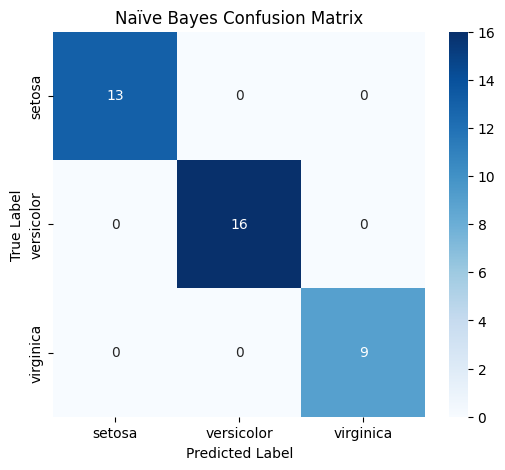

In [ ]:
# 0. Install a compatible scikit-learn version and restart runtime
!pip install scikit-learn==1.2.2 --quiet
# After running this cell, please restart the runtime (Runtime -> Restart runtime) then run all cells again.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. Load Iris dataset
X, y = load_iris(return_X_y=True)
iris = load_iris()

# 2. Split dataset into train and test sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# 3. Train Gaussian Naïve Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# 4. Predict on test data
pred = nb.predict(X_test)

# 5. Output Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, pred))
cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)

# 6. Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.title("Naïve Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Accuracy: 1.0
Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]


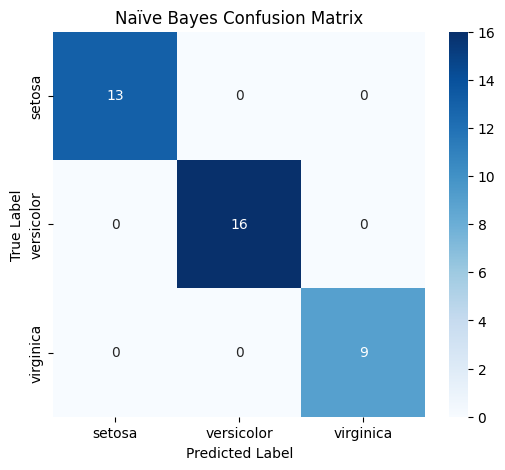

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Split dataset into train and test sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# 3. Train Gaussian Naïve Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# 4. Predict on test data
pred = nb.predict(X_test)

# 5. Output Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, pred))
cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)

# 6. Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.title("Naïve Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

lab 15 — Naïve Bayes Text Classifier (Spam Detection).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Create a sample 'spam.csv' dataset in Google Colab environment
data = {
    'label': [
        'ham', 'spam', 'ham', 'spam', 'ham',
        'spam', 'ham', 'spam', 'ham', 'ham'
    ],
    'message': [
        'Hey, are we still meeting for lunch today?',
        'WINNER!! You have won a $1000 cash prize! Claim now!',
        'Can you send me the project report by evening?',
        'URGENT! Your mobile number has won £2000 bonus credits!',
        'Let us play football this weekend if weather permits.',
        'Free entry in 2 a wk weekly competition to win cash!',
        'I am on my way home now, see you soon.',
        'Congratulations! You are selected for a free holiday package!',
        'Don\'t forget to buy groceries on your way back.',
        'Call me when you get free time.'
    ]
}

pd.DataFrame(data).to_csv('spam.csv', index=False)

# 2. Read dataset and extract relevant columns
df = pd.read_csv('spam.csv', encoding='latin-1')[['label', 'message']]

# 3. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=1
)

# 4. Vectorize text messages using Bag-of-Words (CountVectorizer)
vec = CountVectorizer().fit(X_train)
X_train_v = vec.transform(X_train)
X_test_v = vec.transform(X_test)

# 5. Train Multinomial Naïve Bayes Classifier
model = MultinomialNB().fit(X_train_v, y_train)

# 6. Evaluate accuracy
y_pred = model.predict(X_test_v)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 7. Test custom message predictions
sample_messages = [
    "You won a brand new car! Call now to claim reward!",
    "Hey Mom, I will be home late tonight."
]
sample_vec = vec.transform(sample_messages)
sample_preds = model.predict(sample_vec)

print("\n--- Sample Test Predictions ---")
for msg, pred in zip(sample_messages, sample_preds):
    print(f"Message: '{msg}' --> Prediction: {pred}")

Accuracy: 0.0

--- Sample Test Predictions ---
Message: 'You won a brand new car! Call now to claim reward!' --> Prediction: spam
Message: 'Hey Mom, I will be home late tonight.' --> Prediction: ham


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Automatically generate 'spam.csv' if it doesn't exist in Colab
if not os.path.exists('spam.csv'):
    data = {
        'label': ['ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'ham'],
        'message': [
            'Hey, are we still meeting for lunch today?',
            'WINNER!! You have won a $1000 cash prize! Claim now!',
            'Can you send me the project report by evening?',
            'URGENT! Your mobile number has won £2000 bonus credits!',
            'Let us play football this weekend if weather permits.',
            'Free entry in 2 a wk weekly competition to win cash!',
            'I am on my way home now, see you soon.',
            'Congratulations! You are selected for a free holiday package!',
            'Don\'t forget to buy groceries on your way back.',
            'Call me when you get free time.'
        ]
    }
    pd.DataFrame(data).to_csv('spam.csv', index=False)

# 2. Read dataset
df = pd.read_csv('spam.csv', encoding='latin-1')[['label', 'message']]

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=1
)

# 4. Feature Extraction & Vectorization
vec = CountVectorizer().fit(X_train)
X_train_v = vec.transform(X_train)
X_test_v = vec.transform(X_test)

# 5. Fit Model & Evaluate Accuracy
model = MultinomialNB().fit(X_train_v, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test_v)))

Accuracy: 0.0


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Automatically generate 'spam.csv' if missing
if not os.path.exists('spam.csv'):
    data = {
        'label': ['ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'ham'],
        'message': [
            'Hey, are we still meeting for lunch today?',
            'WINNER!! You have won a $1000 cash prize! Claim now!',
            'Can you send me the project report by evening?',
            'URGENT! Your mobile number has won £2000 bonus credits!',
            'Let us play football this weekend if weather permits.',
            'Free entry in 2 a wk weekly competition to win cash!',
            'I am on my way home now, see you soon.',
            'Congratulations! You are selected for a free holiday package!',
            'Don\'t forget to buy groceries on your way back.',
            'Call me when you get free time.'
        ]
    }
    pd.DataFrame(data).to_csv('spam.csv', index=False)

# 2. Read dataset
df = pd.read_csv('spam.csv', encoding='latin-1')[['label', 'message']]

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=1
)

# 4. Feature Extraction & Vectorization
vec = CountVectorizer().fit(X_train)
X_train_v = vec.transform(X_train)
X_test_v = vec.transform(X_test)

# 5. Fit Model & Evaluate Accuracy
model = MultinomialNB().fit(X_train_v, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test_v)))

Accuracy: 0.0


Lab 19 — Mistake-Bound Model — Halving Algorithm Simulation.

In [ ]:
import math
import random

# 1. Initialize Version Space of 10 threshold hypotheses: h_t(x) = (x >= t)
H = [lambda x, t=t: x >= t for t in range(10)]

# 2. Define target concept: x >= 4
target = lambda x: x >= 4

mistakes = 0
version_space = H.copy()

# 3. Simulate learning process over 10 sample inputs
sample_inputs = random.sample(range(10), 10)

print("--- Halving Algorithm Simulation ---")
for x in sample_inputs:
    if not version_space:
        break

    # Majority vote across remaining hypotheses in version space
    votes = [h(x) for h in version_space]
    majority = sum(votes) > (len(votes) / 2)

    true_label = target(x)

    # Check if prediction made a mistake
    if majority != true_label:
        mistakes += 1
        # Eliminate all hypotheses that voted incorrectly
        version_space = [h for h in version_space if h(x) == true_label]
        print(f"Mistake at x = {x}: Majority predicted {majority}, True = {true_label}. Remaining hypotheses: {len(version_space)}")
    else:
        print(f"Correct prediction at x = {x}: Predicted {majority}")

# 4. Output results and compare against mistake bound
theoretical_bound = round(math.log2(len(H)), 2)
print("\n--- Final Results ---")
print(f"Total Mistakes Made: {mistakes}")
print(f"Theoretical Mistake Bound (log2|H|): {theoretical_bound}")

--- Halving Algorithm Simulation ---
Correct prediction at x = 7: Predicted True
Mistake at x = 4: Majority predicted False, True = True. Remaining hypotheses: 5
Mistake at x = 3: Majority predicted True, True = False. Remaining hypotheses: 1
Correct prediction at x = 5: Predicted True
Correct prediction at x = 8: Predicted True
Correct prediction at x = 9: Predicted True
Correct prediction at x = 0: Predicted False
Correct prediction at x = 6: Predicted True
Correct prediction at x = 1: Predicted False
Correct prediction at x = 2: Predicted False

--- Final Results ---
Total Mistakes Made: 2
Theoretical Mistake Bound (log2|H|): 3.32


lab 20 — Sample Complexity / PAC Bound Calculator.

In [ ]:
import math

# 1. PAC Bound Sample Complexity Function
def sample_complexity(H_size, epsilon, delta):
    """
    Calculates sample complexity m for finite hypothesis space |H|,
    error parameter epsilon (ε), and confidence parameter delta (δ).
    """
    m = (1 / epsilon) * (math.log(H_size) + math.log(1 / delta))
    return math.ceil(m)

# 2. Parameters
epsilon = 0.1  # Error parameter (ε)
delta = 0.05   # Confidence parameter (δ)

print(f"PAC Bound Parameters: ε = {epsilon}, δ = {delta} (95% confidence)\n")
print(f"{'|H| (Hypothesis Space Size)':<30} | {'Minimum Examples Required (m)':<30}")
print("-" * 65)

# 3. Compute required samples for varying hypothesis space sizes
for H_size in [10, 100, 1000, 10000]:
    m = sample_complexity(H_size, epsilon=epsilon, delta=delta)
    print(f"{H_size:<30} | m >= {m} examples")

PAC Bound Parameters: ε = 0.1, δ = 0.05 (95% confidence)

|H| (Hypothesis Space Size)    | Minimum Examples Required (m) 
-----------------------------------------------------------------
10                             | m >= 53 examples
100                            | m >= 77 examples
1000                           | m >= 100 examples
10000                          | m >= 123 examples


Lab 21 — K-Nearest Neighbour Classifier (Iris Dataset).

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Iris dataset
iris = load_iris()

# 2. Split dataset into train (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=1
)

# 3. Train KNN Classifier (k = 5)
model = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

# 4. Predict on test set
y_pred = model.predict(X_test)

# 5. Output Accuracy and Classification Report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Display Correct vs. Wrong Predictions
print("-" * 50)
print(f"{'Actual Class':<20} | {'Predicted Class':<20} | Status")
print("-" * 50)
for actual, pred in zip(y_test, y_pred):
    status = "Correct" if actual == pred else "WRONG"
    actual_name = iris.target_names[actual]
    pred_name = iris.target_names[pred]
    print(f"{actual_name:<20} | {pred_name:<20} | {status}")

Accuracy: 0.9777777777777777

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.95      1.00      0.97        18
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45

--------------------------------------------------
Actual Class         | Predicted Class      | Status
--------------------------------------------------
setosa               | setosa               | Correct
versicolor           | versicolor           | Correct
versicolor           | versicolor           | Correct
setosa               | setosa               | Correct
virginica            | virginica            | Correct
versicolor           | versicolor           | Correct
virginica            | virginica            | Correct
setosa               | setosa   

Lab 22 — K-Nearest Neighbour Regression.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load California Housing Dataset
data = fetch_california_housing()

# 2. Split dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=1
)

# 3. Train KNN Regressor model (k = 7)
model = KNeighborsRegressor(n_neighbors=7).fit(X_train, y_train)

# 4. Predict continuous target values for test instances
pred = model.predict(X_test)

# 5. Evaluate and print regression metrics
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print(f"RMSE: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

# 6. Display first 5 actual vs predicted values
print("\n--- Sample Predictions ---")
for actual, predicted in zip(y_test[:5], pred[:5]):
    print(f"Actual: ${actual * 100000:.2f} | Predicted: ${predicted * 100000:.2f}")

RMSE: 1.0565
R^2 Score: 0.1490

--- Sample Predictions ---
Actual: $355000.00 | Predicted: $191485.71
Actual: $70700.00 | Predicted: $123085.71
Actual: $229400.00 | Predicted: $198371.43
Actual: $112500.00 | Predicted: $141042.86
Actual: $225400.00 | Predicted: $194100.00


Lab 23 — Distance-Weighted KNN.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. Fit Uniform-Weighted KNN (weights='uniform')
uniform = KNeighborsClassifier(n_neighbors=5, weights='uniform').fit(
    X_train, y_train
)

# 4. Fit Distance-Weighted KNN (weights='distance')
distance = KNeighborsClassifier(n_neighbors=5, weights='distance').fit(
    X_train, y_train
)

# 5. Evaluate and Compare Accuracies
pred_uniform = uniform.predict(X_test)
pred_distance = distance.predict(X_test)

acc_uniform = accuracy_score(y_test, pred_uniform)
acc_distance = accuracy_score(y_test, pred_distance)

print(f"Uniform-weighted accuracy : {acc_uniform:.4f}")
print(f"Distance-weighted accuracy: {acc_distance:.4f}")

# 6. Side-by-Side Prediction Comparison Table
results = pd.DataFrame({
    'Actual': [iris.target_names[i] for i in y_test[:10]],
    'Uniform Pred': [iris.target_names[i] for i in pred_uniform[:10]],
    'Distance Pred': [iris.target_names[i] for i in pred_distance[:10]],
})
print("\n--- Sample Comparison (First 10 Test Instances) ---")
print(results.to_string(index=False))

Uniform-weighted accuracy : 0.9778
Distance-weighted accuracy: 0.9778

--- Sample Comparison (First 10 Test Instances) ---
    Actual Uniform Pred Distance Pred
    setosa       setosa        setosa
versicolor   versicolor    versicolor
versicolor   versicolor    versicolor
    setosa       setosa        setosa
 virginica    virginica     virginica
versicolor   versicolor    versicolor
 virginica    virginica     virginica
    setosa       setosa        setosa
    setosa       setosa        setosa
 virginica    virginica     virginica


Lab 24 — Locally Weighted Regression (LWR) from Scratch.

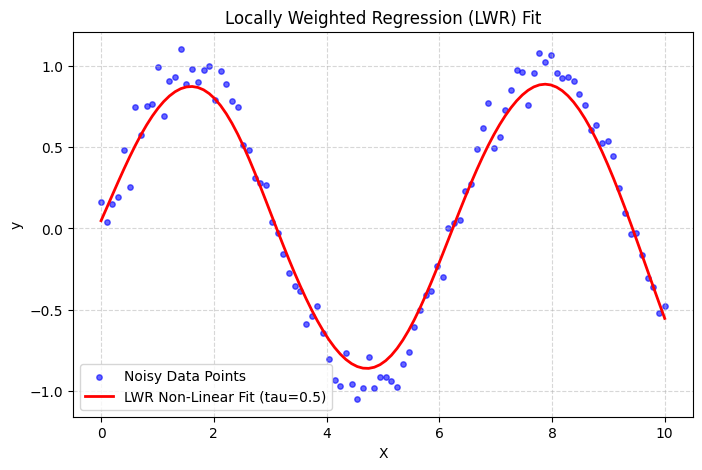

Sample LWR Predictions (first 5 points): [0.04742335 0.12686034 0.20682793 0.28614005 0.36364805]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Locally Weighted Regression function
def lwr(x_query, X, y, tau=0.5):
    """
    Fits a local linear model around x_query using Gaussian weights.
    tau: bandwidth hyperparameter controlling locality smoothness
    """
    m = X.shape[0]
    # Compute Gaussian distance weights
    weights = np.exp(-((X - x_query) ** 2) / (2 * (tau ** 2)))

    # Construct feature matrix with bias column [1, x]
    Xb = np.c_[np.ones(m), X]
    W = np.diag(weights)

    # Solve weighted least-squares: theta = (X^T W X)^-1 X^T W y
    theta = np.linalg.pinv(Xb.T @ W @ Xb) @ Xb.T @ W @ y

    # Predict value at x_query
    return np.array([1, x_query]) @ theta

# 2. Generate noisy sine wave dataset
np.random.seed(1)
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(0, 0.1, 100)

# 3. Compute LWR predictions across input domain
y_pred = np.array([lwr(x, X, y, tau=0.5) for x in X])

# 4. Plot noisy training data vs LWR smooth fit
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=15, color='blue', alpha=0.6, label='Noisy Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label='LWR Non-Linear Fit (tau=0.5)')
plt.title("Locally Weighted Regression (LWR) Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('lwr_fit.png')
plt.show()

# 5. Output sample predictions
print("Sample LWR Predictions (first 5 points):", y_pred[:5])

Lab 25 — Radial Basis Function (RBF) Network.

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Install a compatible scikit-learn version and restart runtime
!pip install scikit-learn==1.2.2 --quiet
# After running this cell, please restart the runtime (Runtime -> Restart runtime) then run all cells again.

# 1. Load Iris dataset
X, y = load_iris(return_X_y=True)

# 2. Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. Use K-Means clustering to find 10 RBF center prototypes
n_centers = 10
kmeans = KMeans(n_clusters=n_centers, random_state=1, n_init=10).fit(X_train)
centres = kmeans.cluster_centers_
sigma = 1.0


# 4. Define Gaussian RBF Transformation function
def rbf_transform(X_data, cluster_centers, std_dev):
    """
    Transforms input vectors X into RBF activations relative to cluster centers.
    """
    return np.array([
        [
            np.exp(-np.sum((x - c) ** 2) / (2 * (std_dev**2)))
            for c in cluster_centers
        ]
        for x in X_data
    ])


# 5. Transform training and test features into RBF feature space
X_train_rbf = rbf_transform(X_train, centres, sigma)
X_test_rbf = rbf_transform(X_test, centres, sigma)

# 6. Fit Logistic Regression classifier on the RBF representation
clf = LogisticRegression(max_iter=1000).fit(X_train_rbf, y_train)

# 7. Evaluate model performance on held-out test data
y_pred = clf.predict(X_test_rbf)
accuracy = accuracy_score(y_test, y_pred)

print("--- RBF Network Results ---")
print(f"Number of RBF Centers: {n_centers}")
print(f"Gaussian Spread (sigma): {sigma}")
print(f"Accuracy: {accuracy:.4f}")

ImportError: cannot import name '_randomized_svd' from 'sklearn.utils.extmath' (/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py)

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Install a compatible scikit-learn version and restart runtime
!pip install scikit-learn==1.2.2 --quiet
# After running this cell, please restart the runtime (Runtime -> Restart runtime) then run all cells again.

# 1. Load dataset
X, y = load_iris(return_X_y=True)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. K-Means clustering to find 10 centers
kmeans = KMeans(n_clusters=10, random_state=1, n_init=10).fit(X_train)
centres = kmeans.cluster_centers_
sigma = 1.0

# 4. RBF Transformation function
def rbf_transform(X_data, cluster_centers, std_dev):
    return np.array([
        [
            np.exp(-np.sum((x - c) ** 2) / (2 * (std_dev**2)))
            for c in cluster_centers
        ]
        for x in X_data
    ])

# 5. Transform features
X_train_rbf = rbf_transform(X_train, centres, sigma)
X_test_rbf = rbf_transform(X_test, centres, sigma)

# 6. Fit Logistic Regression on RBF space
clf = LogisticRegression(max_iter=1000).fit(X_train_rbf, y_train)

# 7. Print Accuracy
print("Accuracy:", accuracy_score(y_test, clf.predict(X_test_rbf)))

ImportError: cannot import name '_randomized_svd' from 'sklearn.utils.extmath' (/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py)

Lab 26 — Case-Based Reasoning (Simple CBR System).

In [ ]:
# 1. Initialize stored Case Library
case_library = [
    {"symptoms": {"fever": True, "cough": True, "fatigue": False}, "diagnosis": "Flu"},
    {"symptoms": {"fever": False, "cough": True, "fatigue": True}, "diagnosis": "Cold"},
    {"symptoms": {"fever": True, "cough": False, "fatigue": True}, "diagnosis": "Viral Infection"},
]

# 2. Define Similarity Function (Counts matching symptom boolean values)
def similarity(a, b):
    return sum(1 for k in a if a[k] == b.get(k))

# 3. Retrieve Function (Finds case with maximum feature similarity score)
def retrieve(new_case):
    scored = [(similarity(new_case, c["symptoms"]), c) for c in case_library]
    return max(scored, key=lambda x: x[0])[1]

# 4. Input New Query Symptoms
new_symptoms = {"fever": True, "cough": True, "fatigue": False}

print("Initial Case Library Size:", len(case_library))

# 5. CBR Cycle Steps: Retrieve & Reuse
best_case = retrieve(new_symptoms)
print("Retrieved Diagnosis (Reuse):", best_case["diagnosis"])

# 6. CBR Cycle Step: Retain (Store new case and its solution in library)
case_library.append({"symptoms": new_symptoms, "diagnosis": best_case["diagnosis"]})
print("Case Library Size after Retain:", len(case_library))

Initial Case Library Size: 3
Retrieved Diagnosis (Reuse): Flu
Case Library Size after Retain: 4


Lab 27 — NumPy Array Creation and Basic Operations

In [ ]:
import numpy as np

# 1. Array Creation Methods
a = np.array([1, 2, 3, 4])
b = np.zeros((3, 3))
c = np.ones((2, 4))
d = np.arange(0, 10, 2)
e = np.linspace(0, 1, 5)

# 2. Inspect Array Properties
print("--- Array Properties ---")
print("a:", a)
print("Shape:", a.shape)
print("Data Type:", a.dtype)
print("Dimensions:", a.ndim)

print("\n--- Array Creation Methods ---")
print("Zeros (3x3):\n", b)
print("Ones (2x4):\n", c)
print("Arange (0 to 10 step 2):", d)
print("Linspace (0 to 1 split into 5):", e)

# 3. Basic Arithmetic & Universal Functions
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

print("\n--- Mathematical Operations ---")
print("x + y  (Addition):", x + y)
print("x * y  (Element-wise Multiplication):", x * y)
print("Dot Product:", np.dot(x, y))
print("sqrt(x):", np.sqrt(x))
print("exp(x) :", np.exp(x))

--- Array Properties ---
a: [1 2 3 4]
Shape: (4,)
Data Type: int64
Dimensions: 1

--- Array Creation Methods ---
Zeros (3x3):
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Ones (2x4):
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
Arange (0 to 10 step 2): [0 2 4 6 8]
Linspace (0 to 1 split into 5): [0.   0.25 0.5  0.75 1.  ]

--- Mathematical Operations ---
x + y  (Addition): [5 7 9]
x * y  (Element-wise Multiplication): [ 4 10 18]
Dot Product: 32
sqrt(x): [1.         1.41421356 1.73205081]
exp(x) : [ 2.71828183  7.3890561  20.08553692]


Lab 28 — NumPy Indexing and Filtering.

In [ ]:
import numpy as np

# 1. Create 1D array and reshape to a 3x4 2D matrix
a = np.arange(12).reshape(3, 4)
print("Original 3x4 Array:\n", a)

# 2. Multi-dimensional indexing and slicing
print("\n--- Indexing & Slicing ---")
print("Element at row 1, col 2 (a[1, 2]):", a[1, 2])
print("Column 1 (all rows):", a[:, 1])
print("Sub-matrix (rows 0-1, cols 2-3):\n", a[:2, 2:])

# 3. Boolean filtering using masks
print("\n--- Boolean Filtering ---")
mask = a > 5
print("Elements > 5:", a[mask])

# 4. Conditional assignment using boolean masks
a[a % 2 == 0] = 0
print("\n--- After zeroing even numbers ---\n", a)

Original 3x4 Array:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

--- Indexing & Slicing ---
Element at row 1, col 2 (a[1, 2]): 6
Column 1 (all rows): [1 5 9]
Sub-matrix (rows 0-1, cols 2-3):
 [[2 3]
 [6 7]]

--- Boolean Filtering ---
Elements > 5: [ 6  7  8  9 10 11]

--- After zeroing even numbers ---
 [[ 0  1  0  3]
 [ 0  5  0  7]
 [ 0  9  0 11]]


Lab 29 — NumPy Statistics and Aggregation.

In [ ]:
import numpy as np

# 1. Initialize a 2x3 NumPy matrix
a = np.array([[1, 2, 3], [4, 5, 6]])
print("Input Matrix (a):\n", a)

# 2. Compute Global Statistics
print("\n--- Global Statistics ---")
print("Overall Mean:", a.mean())
print("Overall Standard Deviation:", a.std())
print("Overall Minimum Value:", a.min())
print("Overall Maximum Value:", a.max())

# 3. Compute Axis-Specific Aggregations
print("\n--- Axis-Specific Aggregations ---")
print("Sum along axis 0 (column-wise sums):", a.sum(axis=0))
print("Sum along axis 1 (row-wise sums)   :", a.sum(axis=1))
print("Minimum along axis 1 (min per row) :", a.min(axis=1))
print("Maximum along axis 0 (max per col) :", a.max(axis=0))

Input Matrix (a):
 [[1 2 3]
 [4 5 6]]

--- Global Statistics ---
Overall Mean: 3.5
Overall Standard Deviation: 1.707825127659933
Overall Minimum Value: 1
Overall Maximum Value: 6

--- Axis-Specific Aggregations ---
Sum along axis 0 (column-wise sums): [5 7 9]
Sum along axis 1 (row-wise sums)   : [ 6 15]
Minimum along axis 1 (min per row) : [1 4]
Maximum along axis 0 (max per col) : [4 5 6]


Lab 30 — NumPy Random Module for Simulation.

In [ ]:
import numpy as np

# 1. Instantiate a seeded Generator object for reproducibility
rng = np.random.default_rng(seed=42)

# 2. Basic Random Number Generation
print("--- Random Sampling Outputs ---")
print("Uniform random (2x3 matrix):\n", rng.random((2, 3)))
print("\nRandom integers [0, 10):", rng.integers(0, 10, size=5))
print("\nGaussian (Normal) samples (mean=0, std=1):", rng.normal(0, 1, size=5))

# 3. Monte Carlo Simulation to Estimate Pi
n = 100000

# Generate n points in 2D space within the box [0, 1] x [0, 1]
points = rng.random((n, 2))

# Count points residing inside the unit circle quadrant (x^2 + y^2 <= 1)
inside = np.sum(points[:, 0]**2 + points[:, 1]**2 <= 1)
pi_estimate = 4 * inside / n

print("\n--- Monte Carlo Pi Simulation ---")
print(f"Total Points Sampled: {n:,}")
print(f"Estimated value of Pi: {pi_estimate}")
print(f"Error relative to np.pi: {abs(pi_estimate - np.pi):.5f}")

--- Random Sampling Outputs ---
Uniform random (2x3 matrix):
 [[0.77395605 0.43887844 0.85859792]
 [0.69736803 0.09417735 0.97562235]]

Random integers [0, 10): [7 7 7 7 5]

Gaussian (Normal) samples (mean=0, std=1): [-0.85304393  0.87939797  0.77779194  0.0660307   1.12724121]

--- Monte Carlo Pi Simulation ---
Total Points Sampled: 100,000
Estimated value of Pi: 3.15012
Error relative to np.pi: 0.00853


Lab 31 — Saving and Loading Data with NumPy.

In [ ]:
import os
import numpy as np

# 1. Create a 2D NumPy array
a = np.array([[1, 2, 3], [4, 5, 6]])
print("Original Array:\n", a)

# 2. Save array to binary (.npy) and plain-text CSV (.csv) formats
np.save('array.npy', a)
np.savetxt('array.csv', a, delimiter=',', fmt='%d')

print("\nFiles successfully created in Colab environment:")
print(" - array.npy (Binary format)")
print(" - array.csv (Text CSV format)")

# 3. Load arrays back from disk
loaded_npy = np.load('array.npy')
loaded_csv = np.loadtxt('array.csv', delimiter=',')

# 4. Display reloaded data and verify shapes
print("\n--- Reloaded Data ---")
print("Loaded from .npy:\n", loaded_npy)
print("Data Type (.npy):", loaded_npy.dtype)

print("\nLoaded from .csv:\n", loaded_csv)
print("Data Type (.csv):", loaded_csv.dtype)

# 5. Clean up generated files (Optional)
os.remove('array.npy')
os.remove('array.csv')

Original Array:
 [[1 2 3]
 [4 5 6]]

Files successfully created in Colab environment:
 - array.npy (Binary format)
 - array.csv (Text CSV format)

--- Reloaded Data ---
Loaded from .npy:
 [[1 2 3]
 [4 5 6]]
Data Type (.npy): int64

Loaded from .csv:
 [[1. 2. 3.]
 [4. 5. 6.]]
Data Type (.csv): float64


Lab 32 — Pandas DataFrame Creation and Combining.

In [ ]:
import pandas as pd

# 1. Construct initial DataFrames from dictionaries
df1 = pd.DataFrame({'name': ['A', 'B', 'C'], 'marks': [80, 90, 70]})
df2 = pd.DataFrame({'name': ['D'], 'marks': [85]})

print("--- Initial DataFrames ---")
print("df1:\n", df1)
print("\ndf2:\n", df2)

# 2. Concatenate DataFrames vertically (Row Stacking)
combined = pd.concat([df1, df2], ignore_index=True)
print("\n--- Concatenated (pd.concat) ---")
print(combined)

# 3. Construct a third DataFrame containing additional attributes
df3 = pd.DataFrame({'name': ['A', 'B', 'C'], 'grade': ['A', 'A+', 'B']})

# 4. Merge DataFrames on a common key ('name') via Inner Join
merged = pd.merge(df1, df3, on='name', how='inner')
print("\n--- Merged (pd.merge on 'name') ---")
print(merged)

--- Initial DataFrames ---
df1:
   name  marks
0    A     80
1    B     90
2    C     70

df2:
   name  marks
0    D     85

--- Concatenated (pd.concat) ---
  name  marks
0    A     80
1    B     90
2    C     70
3    D     85

--- Merged (pd.merge on 'name') ---
  name  marks grade
0    A     80     A
1    B     90    A+
2    C     70     B


Lab 33 — Pandas File I/O (Reading and Writing CSV).

In [ ]:
import os
import pandas as pd

# 1. Create a sample 'students.csv' file to ensure code is self-contained
sample_data = """name,marks
A,80
B,90
C,40
D,85
E,35"""

with open('students.csv', 'w') as f:
    f.write(sample_data)

print("Created sample 'students.csv' file.")

# 2. Read data from CSV file into a DataFrame
df = pd.read_csv('students.csv')
print("\n--- Loaded Data (df.head()) ---")
print(df.head())

# 3. Process data: Add a boolean column checking if marks >= 50
df['pass'] = df['marks'] >= 50

# 4. Write processed DataFrame back to a new CSV file
df.to_csv('students_processed.csv', index=False)

# 5. Display confirmation and preview processed DataFrame
print("\n'students_processed.csv' successfully saved. Preview:")
print(df.head())

# 6. Optional: Clean up created CSV files from the Colab environment
os.remove('students.csv')
os.remove('students_processed.csv')

Created sample 'students.csv' file.

--- Loaded Data (df.head()) ---
  name  marks
0    A     80
1    B     90
2    C     40
3    D     85
4    E     35

'students_processed.csv' successfully saved. Preview:
  name  marks   pass
0    A     80   True
1    B     90   True
2    C     40  False
3    D     85   True
4    E     35  False


Lab 34 — Pandas Grouping and Aggregation.

In [ ]:
import pandas as pd

# 1. Create a sample DataFrame with categorical 'class' and continuous 'marks'
df = pd.DataFrame({
    'class': ['I', 'II', 'I', 'II', 'I', 'II'],
    'marks': [78, 85, 92, 66, 74, 88],
})

print("--- Raw Input DataFrame ---")
print(df)

# 2. Compute mean marks grouped by class
mean_marks = df.groupby('class')['marks'].mean()
print("\n--- Single Aggregate: Mean Marks per Class ---")
print(mean_marks)

# 3. Compute multiple aggregate statistics using .agg()
multi_agg = df.groupby('class')['marks'].agg(['mean', 'max', 'min', 'count'])
print("\n--- Multiple Aggregates per Class ---")
print(multi_agg)

--- Raw Input DataFrame ---
  class  marks
0     I     78
1    II     85
2     I     92
3    II     66
4     I     74
5    II     88

--- Single Aggregate: Mean Marks per Class ---
class
I     81.333333
II    79.666667
Name: marks, dtype: float64

--- Multiple Aggregates per Class ---
            mean  max  min  count
class                            
I      81.333333   92   74      3
II     79.666667   88   66      3


Lab 35 — Pandas Filtering and Sorting.

In [ ]:
import pandas as pd

# 1. Create sample DataFrame
df = pd.DataFrame({
    'name': ['A', 'B', 'C', 'D'],
    'class': ['I', 'II', 'I', 'II'],
    'marks': [78, 85, 92, 66],
})

print("--- Original DataFrame ---")
print(df)

# 2. Filter rows using multiple boolean conditions (&)
filtered = df[(df['marks'] > 70) & (df['class'] == 'I')]
print("\n--- Filtered (marks > 70 AND class == 'I') ---")
print(filtered)

# 3. Sort DataFrame by multiple columns ('class' ASC, 'marks' DESC)
sorted_df = df.sort_values(['class', 'marks'], ascending=[True, False])
print("\n--- Sorted (class Ascending, marks Descending) ---")
print(sorted_df)

--- Original DataFrame ---
  name class  marks
0    A     I     78
1    B    II     85
2    C     I     92
3    D    II     66

--- Filtered (marks > 70 AND class == 'I') ---
  name class  marks
0    A     I     78
2    C     I     92

--- Sorted (class Ascending, marks Descending) ---
  name class  marks
2    C     I     92
0    A     I     78
1    B    II     85
3    D    II     66


Lab 36 — Pandas Plotting (Data Visualisation).

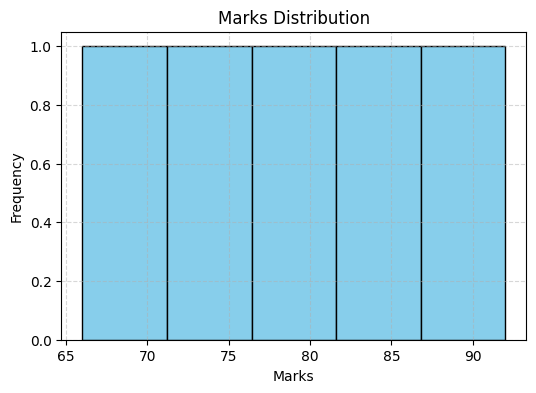

<Figure size 640x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>

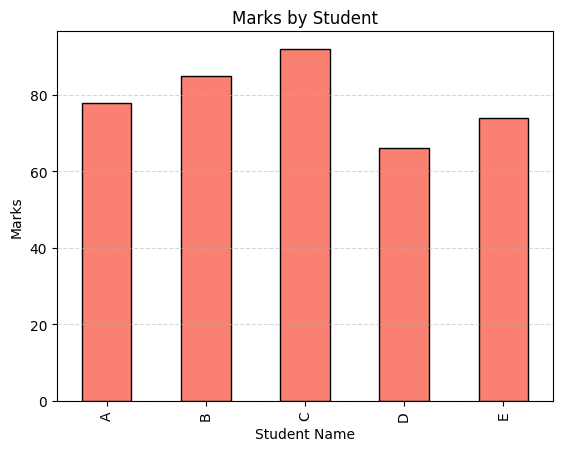

Plots successfully rendered and saved as: 'marks_hist.png', 'marks_bar.png'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create sample DataFrame
df = pd.DataFrame(
    {'name': ['A', 'B', 'C', 'D', 'E'], 'marks': [78, 85, 92, 66, 74]}
)

# 2. Histogram plot: Marks Distribution
plt.figure(figsize=(6, 4))
df['marks'].plot(kind='hist', title='Marks Distribution', bins=5, color='skyblue', edgecolor='black')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('marks_hist.png', bbox_inches='tight')
plt.show()  # Display inline in Colab
plt.clf()   # Clear current figure buffer

# 3. Bar Chart plot: Marks by Student
plt.figure(figsize=(6, 4))
df.plot(x='name', y='marks', kind='bar', title='Marks by Student', legend=False, color='salmon', edgecolor='black')
plt.xlabel('Student Name')
plt.ylabel('Marks')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('marks_bar.png', bbox_inches='tight')
plt.show()  # Display inline in Colab

print("Plots successfully rendered and saved as: 'marks_hist.png', 'marks_bar.png'")

Lab 37 — Data Cleaning with Pandas (Missing Values & Duplicates).

In [ ]:
import numpy as np
import pandas as pd

# 1. Create a sample DataFrame containing missing values (NaN/None) and duplicate rows
df = pd.DataFrame({
    'name': ['A', 'B', 'B', 'C', None],
    'marks': [78, np.nan, 85, 92, 66],
})

print("--- Original Raw DataFrame ---")
print(df)

# 2. Identify missing values per column
print("\n--- Missing Values Count Per Column ---")
print(df.isnull().sum())

# 3. Handle missing values using .fillna()
# Impute categorical missing data with 'Unknown' and numerical with column mean
mean_marks = df['marks'].mean()
df_filled = df.fillna({'name': 'Unknown', 'marks': mean_marks})

print("\n--- After Filling Missing Values (fillna) ---")
print(df_filled)

# 4. Detect and remove duplicate records
print("\nDuplicate rows count:", df_filled.duplicated().sum())

df_clean = df_filled.drop_duplicates()
print("\n--- Final Cleaned DataFrame (drop_duplicates) ---")
print(df_clean)

--- Original Raw DataFrame ---
   name  marks
0     A   78.0
1     B    NaN
2     B   85.0
3     C   92.0
4  None   66.0

--- Missing Values Count Per Column ---
name     1
marks    1
dtype: int64

--- After Filling Missing Values (fillna) ---
      name  marks
0        A  78.00
1        B  80.25
2        B  85.00
3        C  92.00
4  Unknown  66.00

Duplicate rows count: 0

--- Final Cleaned DataFrame (drop_duplicates) ---
      name  marks
0        A  78.00
1        B  80.25
2        B  85.00
3        C  92.00
4  Unknown  66.00


Lab 38 — End-to-End Mini ML Pipeline

In [ ]:
import os
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Create a self-contained 'iris.csv' file to ensure error-free execution
raw_iris = load_iris(as_frame=True)
df_iris = raw_iris.frame
df_iris.columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species',
]
df_iris['species'] = df_iris['species'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
)
df_iris.to_csv('iris.csv', index=False)
print("Created sample 'iris.csv' dataset.")

# 2. Pipeline Step 1: Load & Clean Data
df = pd.read_csv('iris.csv').dropna()

# 3. Pipeline Step 2: Encode Target Column
le = LabelEncoder()
df['species_enc'] = le.fit_transform(df['species'])

X = df.drop(columns=['species', 'species_enc'])
y = df['species_enc']

# 4. Pipeline Step 3: Train-Test Split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 5. Pipeline Step 4: Feature Scaling (Standardization)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Pipeline Step 5: Train KNN Model & Predict
model = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)

# 7. Evaluate and Decode Predictions
print("\n--- Pipeline Results ---")
print(f"Pipeline Accuracy: {accuracy_score(y_test, pred):.4f}")
print("Sample predictions (decoded):", le.inverse_transform(pred[:5]))

# 8. Clean up temporary CSV file
os.remove('iris.csv')

Created sample 'iris.csv' dataset.

--- Pipeline Results ---
Pipeline Accuracy: 0.9556
Sample predictions (decoded): ['setosa' 'versicolor' 'versicolor' 'setosa' 'virginica']


Lab 39 — Model Evaluation Metrics

In [ ]:
from sklearn.datasets import load_iris
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Load dataset
X, y = load_iris(return_X_y=True)

# 2. Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)

# 4. Predict on Test Data
pred = clf.predict(X_test)

# 5. Compute & Print Classification Metrics
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, pred))

print("\n--- Model Evaluation Metrics ---")
print("Accuracy         :", accuracy_score(y_test, pred))
print("Precision (macro):", precision_score(y_test, pred, average='macro'))
print("Recall (macro)   :", recall_score(y_test, pred, average='macro'))
print("F1-score (macro) :", f1_score(y_test, pred, average='macro'))

--- Confusion Matrix ---
[[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]

--- Model Evaluation Metrics ---
Accuracy         : 0.9555555555555556
Precision (macro): 0.9558404558404558
Recall (macro)   : 0.9558404558404558
F1-score (macro) : 0.9558404558404558


Lab 40 — Capstone: Complete Machine Learning Pipeline with Visualisation.

--- Dataset Summary Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

--- Model Training & Evaluation ---


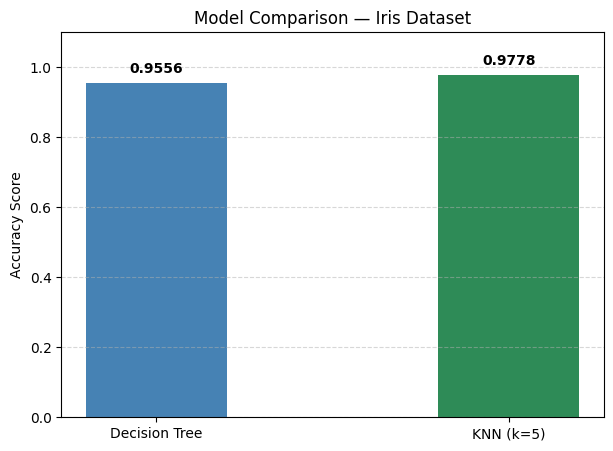

Comparison plot saved as 'model_comparison.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Load and Explore Dataset (Pandas)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("--- Dataset Summary Statistics ---")
print(df.describe())

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df.iloc[:, :-1], df['target'], test_size=0.3, random_state=1
)

# 3. Initialize Models for Comparison
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=1),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

# 4. Train, Predict, and Evaluate
results = {}
print("\n--- Model Training & Evaluation ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 5. Visualize Results with a Bar Chart (Matplotlib)
plt.figure(figsize=(7, 5))
bars = plt.bar(
    results.keys(), results.values(), color=['steelblue', 'seagreen'], width=0.4
)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)
plt.title('Model Comparison — Iris Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate exact accuracy values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.02,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
    )

# Save and Display Plot
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

print("Comparison plot saved as 'model_comparison.png'")